# Bottleneck N-T Diagram With Zone Speed Factor

This notebook runs the shared community bottleneck example twice and compares the resulting $N$-$T$ diagrams at the bottleneck throat.

- Run 1 uses zone `speed_factor = 1.0`
- Run 2 uses zone `speed_factor = 0.5`

The final plot shows both runs side by side using `pedpy.plot_nt(..., axes=...)`.

In [1]:
import logging
from datetime import datetime

# Silence jupedsim-scenarios' INFO/DEBUG output. See the howto
# "How do I inspect a scenario?" for the full list of levels.
logging.getLogger("jupedsim_scenarios").setLevel(logging.WARNING)

print(f"Executed on {datetime.now().strftime('%d.%m.%Y, %H:%M')}")

from pathlib import Path

import matplotlib.pyplot as plt
import pedpy

from jupedsim_scenarios import load_scenario, run_sweep

Executed on 25.05.2026, 14:15


In [2]:
SCENARIO_DIR = Path("scenario_files") / "bottleneck-zone"
MEASUREMENT_LINE = pedpy.MeasurementLine([(10.0, 4.5), (10.0, 5.5)])

scenario = load_scenario(str(SCENARIO_DIR))
scenario.summary()

'Scenario: /Users/chraibi/workspace/PedestrianDynamics/jupedsim-scenarios/examples/cookbook/scenario_files/bottleneck-zone\n  Model:         CollisionFreeSpeedModel\n  Seed:          42\n  Max time:      300s\n  Exits:         1\n  Distributions: 1\n  Stages:        0\n  Zones:         1\n  Journeys:      1\n  Agents:        ~50\n  Journey elems: 2\n  Route:         1 distribution, 0 checkpoint, 1 exit\n  Sequence:      jps-distributions_0 -> jps-exits_0\n    jps-distributions_0: 50 agents'

## Helper Functions

We deep-copy the loaded scenario data before changing the zone speed factor. This keeps the baseline and modified runs independent, because nested edits to `scenario.raw` would otherwise leak into later runs.

In [3]:
def _nt_from_trial(trial):
    """Post-process one run_sweep trial into the rich dict the
    downstream cells expect (trajectory, n(t) curve, crossing frames).
    """
    traj = pedpy.TrajectoryData(
        trial.result.trajectory_dataframe()[["id", "frame", "x", "y"]],
        frame_rate=trial.result.frame_rate,
    )
    nt, crossing_frames = pedpy.compute_n_t(
        traj_data=traj,
        measurement_line=MEASUREMENT_LINE,
    )
    return {
        "speed_factor": trial.axis_values["speed_factor"],
        "result": trial.result,
        "trajectory": traj,
        "nt": nt,
        "crossing_frames": crossing_frames,
    }

## Baseline Run

First run the bottleneck with zone `speed_factor = 1.0`.

In [4]:
%%capture
# Sweep both speed_factor values through one run_sweep call so the two
# variants execute in parallel (workers=2) and share the per-trial
# .copy()/.cleanup() bookkeeping.
sweep = run_sweep(
    scenario,
    axes={"speed_factor": [1.0, 0.5]},
    apply={
        "speed_factor": lambda s, v: s.set_zone_speed_factor(0, float(v)),
    },
    seeds=[42],
    workers=2,
)
baseline = _nt_from_trial(sweep.trials[0])
slow_zone = _nt_from_trial(sweep.trials[1])
baseline["result"].metrics

## Slowdown Run

Now change the zone speed factor to `0.5` and rerun.

In [5]:
slow_zone["result"].metrics

{'success': True,
 'status': 'completed',
 'message': 'All agents evacuated before reaching the maximum simulation time.',
 'evacuation_time': 59.69,
 'total_agents': 50,
 'agents_evacuated': 50,
 'agents_remaining': 0,
 'all_evacuated': True,
 'frame_rate': 10.0,
 'dt': 0.01,
 'seed': 42,
 'walkable_polygon': <POLYGON ((0 0, 10 0, 10 4.5, 15 4.5, 15 0, 25 0, 25 10, 15 10, 15 5.5, 10 5...>}

## Geometry, Zone, and Trajectories

The panels below show the bottleneck geometry, the slowdown zone polygon, the measurement line, and the trajectories for both runs.

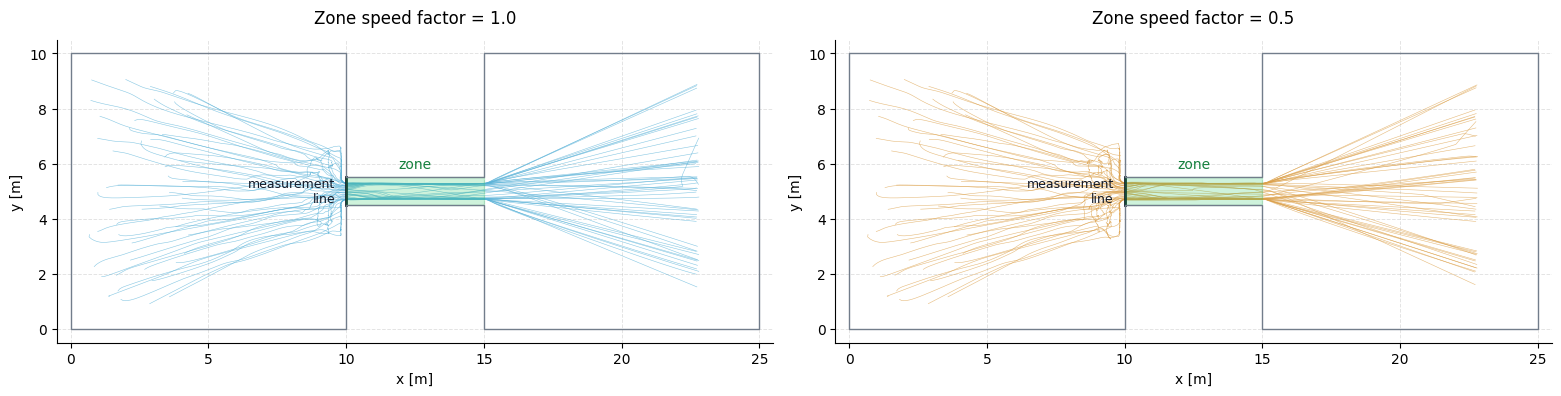

In [6]:
zone_xy = scenario.raw["zones"]["jps-zones_0"]["coordinates"]

fig, axes = plt.subplots(1, 2, figsize=(15.5, 5.8), constrained_layout=True)

for ax, run, color in [
    (axes[0], baseline, pedpy.PEDPY_BLUE),
    (axes[1], slow_zone, pedpy.PEDPY_ORANGE),
]:
    pedpy.plot_measurement_setup(
        traj=run["trajectory"],
        walkable_area=pedpy.WalkableArea(scenario.walkable_polygon),
        measurement_lines=[MEASUREMENT_LINE],
        axes=ax,
        traj_alpha=0.72,
        traj_width=0.4,
        ml_width=2,
        ml_alpha=0.28,
        traj_color=color,
        ml_color="#111827",
    ).set_aspect("equal")
    ax.fill(
        [xy[0] for xy in zone_xy],
        [xy[1] for xy in zone_xy],
        color="#22C55E",
        alpha=0.22,
        zorder=2,
    )
    ax.text(12.5, 5.85, "zone", color="#15803D", fontsize=10, ha="center")
    ax.text(9.6, 5.0, "measurement\nline", color="#111827", fontsize=9, ha="right", va="center")
    ax.set_title(f"Zone speed factor = {run['speed_factor']:.1f}", pad=12)
    ax.set_xlim(-0.5, 25.5)
    ax.set_ylim(-0.5, 10.5)
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.grid(True, linestyle="--", linewidth=0.7, alpha=0.35)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.show()

## Side-By-Side N-T Diagrams

The slower zone should delay cumulative crossings at the measurement line.

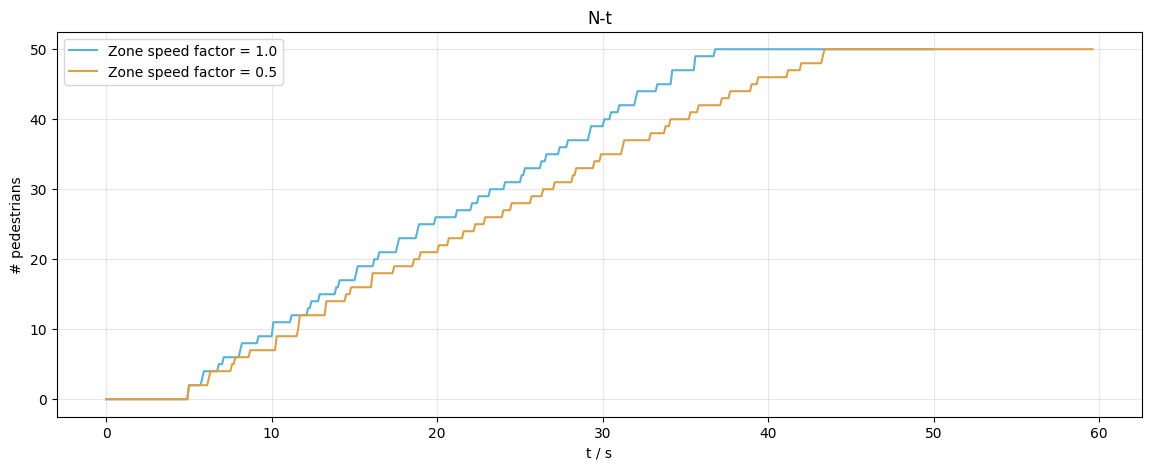

In [7]:
fig, axes = plt.subplots(1, 1, figsize=(14, 5))

pedpy.plot_nt(
    nt=baseline["nt"],
    axes=axes,
    label="Zone speed factor = 1.0",
    color=pedpy.PEDPY_BLUE,
)

pedpy.plot_nt(
    nt=slow_zone["nt"],
    axes=axes,
    label="Zone speed factor = 0.5",
    color=pedpy.PEDPY_ORANGE,    
)
axes.legend()
axes.grid(alpha=0.3)

## Cleanup

Delete the temporary SQLite files when you are done.

In [8]:
baseline["result"].cleanup()
slow_zone["result"].cleanup()